
# [3주차 과제] 축구 이벤트 패스 도착 좌표 예측 모델링 및 평가

## 1. 데이터 로드 및 이전 주차 요약 (Preprocessing & Feature Engineering)

본격적인 모델링에 앞서, 구글 드라이브에 마운트된 `train.csv`를 불러오고 1~2주차에 수행했던 전처리와 피처 엔지니어링을 일괄 수행하여 모델 학습용 데이터셋을 구축합니다.

* **전처리 요약:** 1. `result_name` 결측치는 'Not_Applicable'로 보존
  2. `player_id` 결측치는 불확실한 노이즈로 간주하여 삭제
  3. 이동이 없는 액션의 `end_x`, `end_y` 결측치는 `start_x`, `start_y`로 대체
* **피처 엔지니어링 요약:**
  1. `pitch_zone`: 경기장을 9분할하여 전술적 위치 정보 범주화
  2. `prev_action`: 동일 공격 흐름(episode) 내 직전 액션을 시계열로 파악
  3. `is_gk_zone`: 최후방 빌드업(페널티 박스 내) 여부를 파악하여 킥의 불확실성 통제
  4. `team_wing_ratio`: 구단별 측면 공격 선호도를 수치화하여 타겟 인코딩


# ⚽ [3주차 과제] TASK 1: 모델링 (Modeling)

본 과제에서는 전처리 및 피처 엔지니어링이 완료된 데이터를 활용하여 패스의 도착 좌표(`end_x`, `end_y`)를 예측합니다. 타겟 변수가 2개인 연속형 수치 예측이므로 **다중 출력 회귀(Multi-output Regression)** 문제로 정의합니다.

이번 단계에서는 모델의 성능 평가를 진행하기 전, 3가지 강력한 트리 기반 앙상블 모델을 각각 정의하고 학습(Fit)시키는 과정에 집중합니다.

1. **Random Forest Regressor:** 비선형 데이터 패턴을 잘 파악하며 다중 출력을 기본적으로 지원하는 강력한 베이스라인 모델입니다.
2. **XGBoost Regressor:** 오차(잔차)를 순차적으로 줄여나가는 부스팅 기법의 대표 주자로, 정밀한 예측 능력을 자랑합니다.
3. **LightGBM Regressor:** 대용량 데이터에서 학습 속도가 압도적으로 빠르며, 최신 데이터 분석 대회에서 가장 많이 쓰이는 최적화 모델입니다.

In [14]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 한글 폰트 설정 (코랩 환경)
!pip install koreanize-matplotlib > /dev/null
import koreanize_matplotlib

# 1. 드라이브 마운트 및 전처리된 Train 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

# ⚠️ 본인의 실제 구글 드라이브 경로로 맞춰주세요.
base_dir = '/content/drive/MyDrive'
train_path = f'{base_dir}/preprocessed_train.csv'
df_train = pd.read_csv(train_path)

# 2. 모델 학습용 피처(X)와 타겟(y) 세팅
features = ['start_x', 'start_y', 'is_gk_zone', 'team_wing_ratio', 'pitch_zone', 'prev_action', 'type_name']
X = pd.get_dummies(df_train[features], drop_first=True)
y = df_train[['end_x', 'end_y']]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 [STEP 1] 베이스라인 모델 학습 시작 (Hold-out)...")
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_val)

# XGBoost
xgb_model = MultiOutputRegressor(xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_val)
print("✅ 베이스라인 학습 완료!\n")

print("🚀 [STEP 2] LightGBM 5-Fold 교차 검증 및 학습 시작...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_x = np.zeros(len(X))
oof_pred_y = np.zeros(len(X))
all_evals_results = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_v, y_v = X.iloc[val_idx], y.iloc[val_idx]

    model_x = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1)
    model_y = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1)

    model_x.fit(X_tr, y_tr['end_x'], eval_set=[(X_v, y_v['end_x'])], eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])
    model_y.fit(X_tr, y_tr['end_y'], eval_set=[(X_v, y_v['end_y'])], eval_metric='rmse', callbacks=[lgb.early_stopping(50, verbose=False)])

    oof_pred_x[val_idx] = model_x.predict(X_v)
    oof_pred_y[val_idx] = model_y.predict(X_v)

    all_evals_results.append({
        'x': model_x.evals_result_, 'y': model_y.evals_result_,
        'best_x': model_x.best_iteration_, 'best_y': model_y.best_iteration_
    })
print("✅ LightGBM 5-Fold 학습 완료!\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 [STEP 1] 베이스라인 모델 학습 시작 (Hold-out)...
✅ 베이스라인 학습 완료!

🚀 [STEP 2] LightGBM 5-Fold 교차 검증 및 학습 시작...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 629
[LightGBM] [Info] Number of data points in the train set: 285132, number of used features: 56
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 51.011957
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039013 seconds.
You can set `force_c

## TASK 2: 모델 평가 및 시각화 (Model Evaluation & Visualization)

앞서 학습시킨 3가지 앙상블 모델의 예측 성능을 검증 데이터(Validation, 20%)를 통해 평가합니다. 예측 타겟이 연속형 변수(좌표)이므로 다음 지표들을 활용합니다.

### 1. 평가 지표 (Metrics)
* **MAE (Mean Absolute Error):** 실제 도착 좌표와 예측 좌표 간의 절대적 거리 오차입니다.
* **RMSE (Root Mean Squared Error):** 오차의 제곱에 루트를 씌운 값으로, 크게 빗나간 예측(이상치)에 더 큰 페널티를 부여합니다.
* **R² (R-squared, 결정계수):** 모델이 데이터의 분산을 얼마나 잘 설명하는지 나타내며, 1에 가까울수록 성능이 우수함을 의미합니다.

### 2. 모델 비교 및 해석
* 모델별 RMSE 성능 비교 바 차트(Bar Chart)를 통해 최우수 모델을 선정합니다.
* Random Forest 모델을 기준으로 **피처 중요도(Feature Importance)**를 추출하여, 예측에 가장 큰 기여를 한 변수를 파악합니다.
* 최우수 모델(LightGBM)의 예측값에 대한 **잔차 플롯(Residual Plot)**을 그려 오차의 분포와 물리적 한계선(Boundary)을 확인합니다.

📊 [TASK 2] 모델 성능 평가 (채점) 시작...

[Random Forest 성능]
 - X좌표 | MAE: 7.562, RMSE: 10.918, R²: 0.798
 - Y좌표 | MAE: 7.531, RMSE: 10.544, R²: 0.715

[XGBoost 성능]
 - X좌표 | MAE: 7.275, RMSE: 10.774, R²: 0.803
 - Y좌표 | MAE: 7.344, RMSE: 10.451, R²: 0.720

[LightGBM 성능]
 - X좌표 | MAE: 7.107, RMSE: 10.526, R²: 0.812
 - Y좌표 | MAE: 7.219, RMSE: 10.293, R²: 0.729

--------------------------------------------------
🎨 결과 시각화 생성 중 (모델 비교, 중요도, 잔차 분석)...



/tmp/ipykernel_6315/1225188467.py:87: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


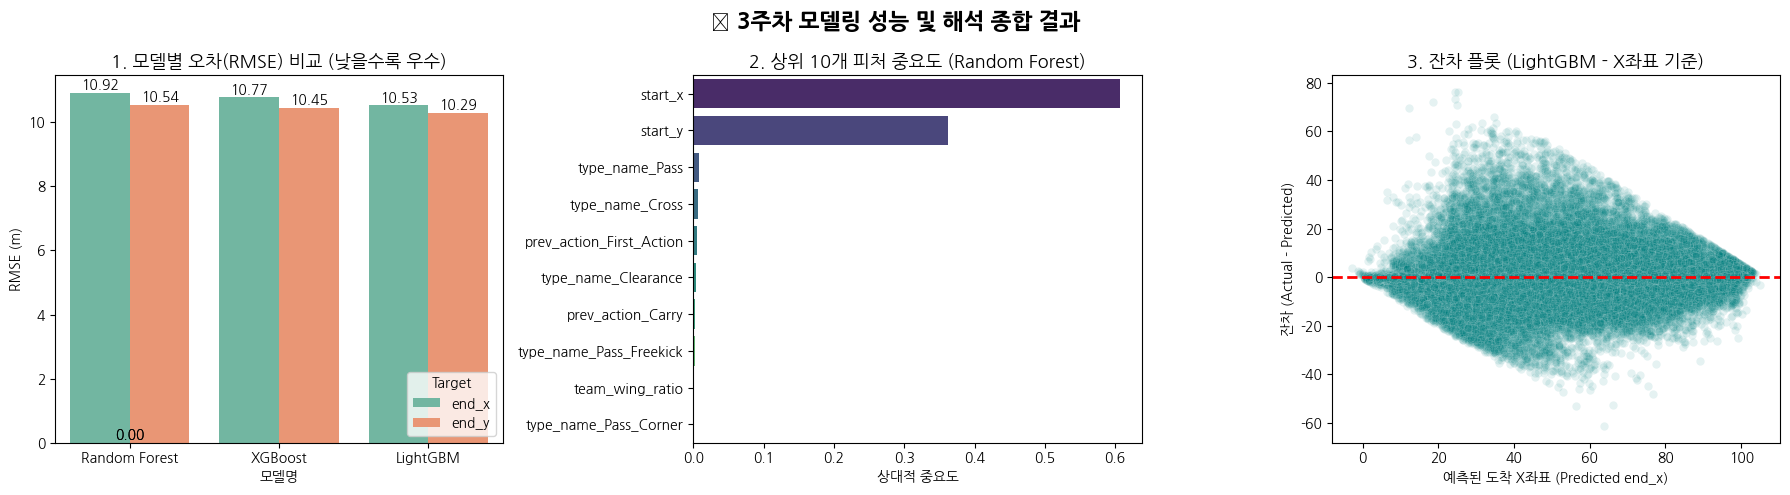

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 한글 폰트 설정 (코랩 환경용)
# !pip install koreanize-matplotlib > /dev/null
import koreanize_matplotlib

print("📊 [TASK 2] 모델 성능 평가 (채점) 시작...\n")

# 1. 평가 지표 계산 및 저장
evaluation_results = []

def evaluate_and_store(name, y_true, y_pred):
    mae_x = mean_absolute_error(y_true['end_x'], y_pred[:, 0])
    mae_y = mean_absolute_error(y_true['end_y'], y_pred[:, 1])
    rmse_x = np.sqrt(mean_squared_error(y_true['end_x'], y_pred[:, 0]))
    rmse_y = np.sqrt(mean_squared_error(y_true['end_y'], y_pred[:, 1]))
    r2_x = r2_score(y_true['end_x'], y_pred[:, 0])
    r2_y = r2_score(y_true['end_y'], y_pred[:, 1])

    print(f"[{name} 성능]")
    print(f" - X좌표 | MAE: {mae_x:.3f}, RMSE: {rmse_x:.3f}, R²: {r2_x:.3f}")
    print(f" - Y좌표 | MAE: {mae_y:.3f}, RMSE: {rmse_y:.3f}, R²: {r2_y:.3f}\n")

    # 시각화를 위해 데이터프레임용 리스트에 저장
    evaluation_results.append({'Model': name, 'Target': 'end_x', 'RMSE': rmse_x})
    evaluation_results.append({'Model': name, 'Target': 'end_y', 'RMSE': rmse_y})

pred_rf = rf_model.predict(X_val)
pred_xgb = xgb_model.predict(X_val)

pred_lgb_x = model_x.predict(X_val)
pred_lgb_y = model_y.predict(X_val)
pred_lgb = np.column_stack((pred_lgb_x, pred_lgb_y))

evaluate_and_store("Random Forest", y_val, pred_rf)
evaluate_and_store("XGBoost", y_val, pred_xgb)
evaluate_and_store("LightGBM", y_val, pred_lgb)

print("-" * 50)
print("🎨 결과 시각화 생성 중 (모델 비교, 중요도, 잔차 분석)...\n")

# =================================================================
# 시각화 1: 모델별 RMSE 성능 비교
# =================================================================
df_eval = pd.DataFrame(evaluation_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🏆 3주차 모델링 성능 및 해석 종합 결과', fontsize=16, fontweight='bold')

sns.barplot(data=df_eval, x='Model', y='RMSE', hue='Target', palette='Set2', ax=axes[0])
axes[0].set_title('1. 모델별 오차(RMSE) 비교 (낮을수록 우수)', fontsize=13)
axes[0].set_ylabel('RMSE (m)')
axes[0].set_xlabel('모델명')

# 바 차트 위에 수치 표시
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# =================================================================
# 시각화 2: 피처 중요도 (Random Forest 기준)
# =================================================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # 상위 10개만 추출
y_features = [X.columns[i] for i in indices]

sns.barplot(x=importances[indices], y=y_features, hue=y_features, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('2. 상위 10개 피처 중요도 (Random Forest)', fontsize=13)
axes[1].set_xlabel('상대적 중요도')

# =================================================================
# 시각화 3: 최우수 모델(LightGBM) 잔차 플롯 (X좌표 기준)
# =================================================================
residuals_x = y_val['end_x'] - pred_lgb[:, 0]

sns.scatterplot(x=pred_lgb[:, 0], y=residuals_x, alpha=0.1, color='teal', ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('3. 잔차 플롯 (LightGBM - X좌표 기준)', fontsize=13)
axes[2].set_xlabel('예측된 도착 X좌표 (Predicted end_x)')
axes[2].set_ylabel('잔차 (Actual - Predicted)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_6315/899282291.py:39: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


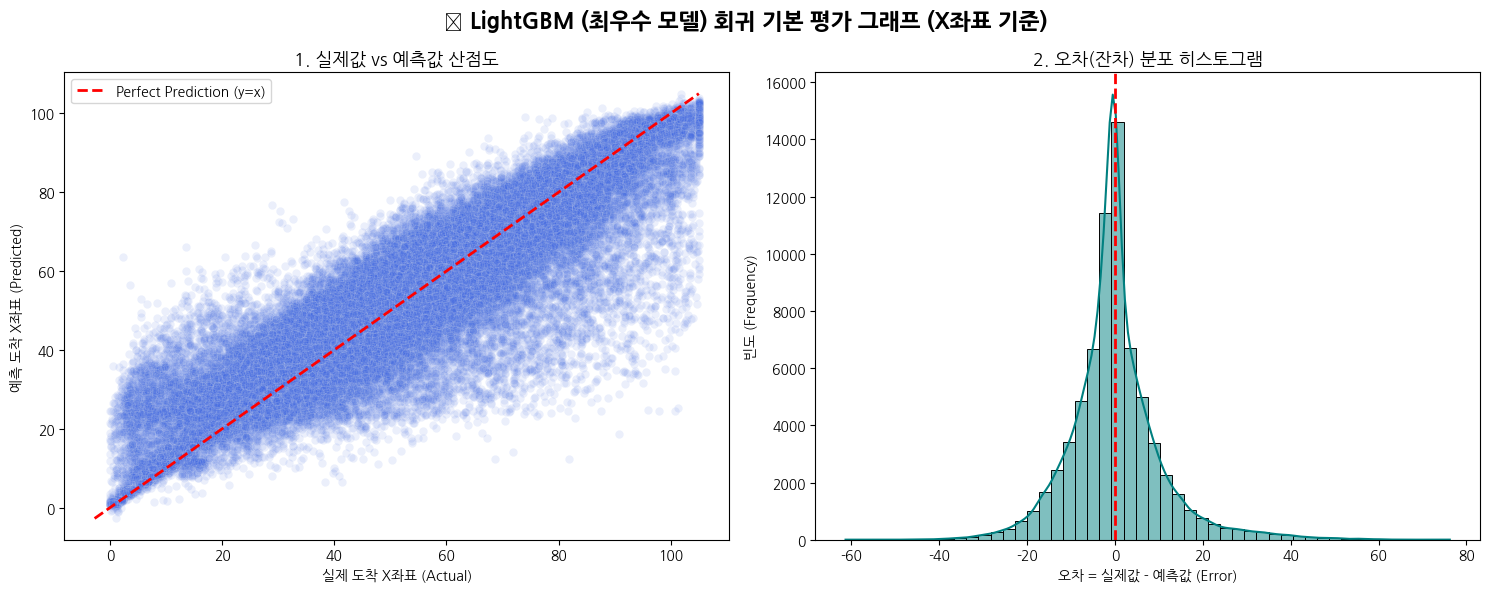

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM의 검증 데이터 예측값과 실제값 준비 (X좌표 기준)
actual_x = y_val['end_x']
predicted_x = pred_lgb[:, 0]
errors_x = actual_x - predicted_x

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🏆 LightGBM (최우수 모델) 회귀 기본 평가 그래프 (X좌표 기준)', fontsize=16, fontweight='bold')

# =================================================================
# 1. 실제값 vs 예측값 산점도 (Actual vs Predicted Plot)
# (분류 문제의 Confusion Matrix 역할을 하는 회귀 기본 그래프입니다)
# =================================================================
sns.scatterplot(x=actual_x, y=predicted_x, alpha=0.1, color='royalblue', ax=axes[0])

# 완벽한 정답을 의미하는 대각선(y=x) 그리기
min_val = min(actual_x.min(), predicted_x.min())
max_val = max(actual_x.max(), predicted_x.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[0].set_title('1. 실제값 vs 예측값 산점도', fontsize=13)
axes[0].set_xlabel('실제 도착 X좌표 (Actual)')
axes[0].set_ylabel('예측 도착 X좌표 (Predicted)')
axes[0].legend()

# =================================================================
# 2. 오차(잔차) 분포 히스토그램 (Error Distribution Histogram)
# (오차가 0을 중심으로 종 모양(정규분포)을 이루는지 확인하는 그래프입니다)
# =================================================================
sns.histplot(errors_x, bins=50, kde=True, color='teal', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('2. 오차(잔차) 분포 히스토그램', fontsize=13)
axes[1].set_xlabel('오차 = 실제값 - 예측값 (Error)')
axes[1].set_ylabel('빈도 (Frequency)')

plt.tight_layout()
plt.show()

## TASK 3: 최종 Test 데이터 예측 및 실제 성능 평가 (Inference & Final Evaluation)

최우수 모델로 선정된 LightGBM을 활용하여, 실제 평가용 데이터인 `test` 데이터셋의 좌표를 예측합니다.
이후 원본 테스트 데이터에 존재하는 실제 도착 좌표(`end_x`, `end_y`)와 모델의 예측 좌표 간의 **유클리드 거리(Euclidean Distance)**를 계산하여, 평균적으로 몇 m의 오차가 발생하는지 최종 평가를 수행합니다.

[TASK 3] Test 데이터 기반 최종 예측 및 실제 성능 평가 시작...



Test 파일 병합 중: 100%|██████████| 2414/2414 [16:24<00:00,  2.45it/s]



Test 데이터 병합 완료 (데이터 크기: (53110, 15))

Test 데이터 전처리 및 파생 변수 생성 중...
LightGBM 모델로 Test 데이터 좌표 예측 중...

[최종 성능 평가 결과 (Test 데이터)]
--------------------------------------------------
평균 오차 거리 (Mean Euclidean Distance)  : 11.08 m
중앙값 오차 거리 (Median Euclidean Distance): 8.89 m
 -> 모델이 예측한 위치에서 평균 11.08m 반경 안에 실제 공이 위치했습니다.
--------------------------------------------------
X좌표 최종 RMSE : 10.62 m
Y좌표 최종 RMSE : 9.89 m
--------------------------------------------------


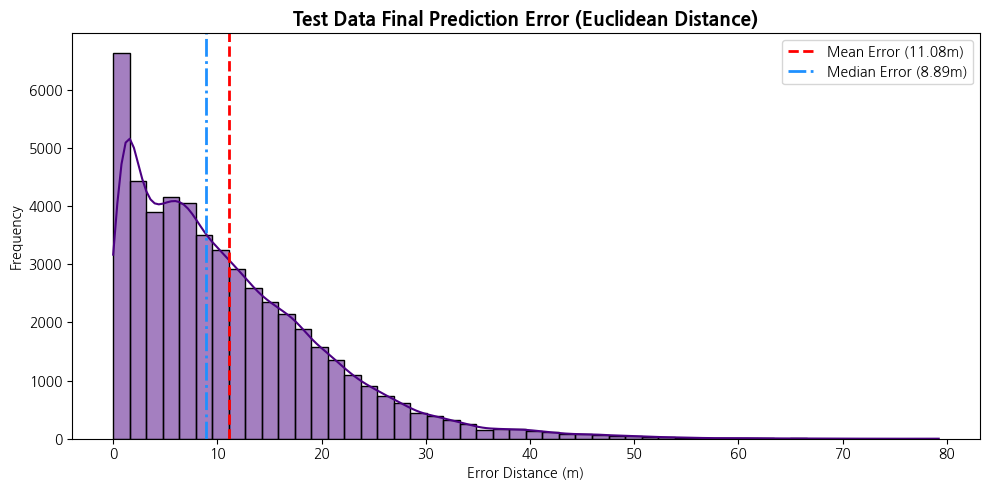

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

print("[TASK 3] Test 데이터 기반 최종 예측 및 실제 성능 평가 시작...\n")

# 1. 파일 경로 설정 (구글 드라이브 기본 경로 기준)
base_dir = '/content/drive/MyDrive/epoch'
test_index_path = f'{base_dir}/test.csv'

# 2. Test 메타데이터 로드 및 폴더 내 조각난 파일 병합
test_index_df = pd.read_csv(test_index_path)
test_data_list = []

for idx, row in tqdm(test_index_df.iterrows(), total=len(test_index_df), desc="Test 파일 병합 중"):
    # 상대 경로를 실제 구글 드라이브 경로로 변환
    actual_path = os.path.join(base_dir, row['path'].replace('./', ''))
    if os.path.exists(actual_path):
        test_data_list.append(pd.read_csv(actual_path))

test_df = pd.concat(test_data_list, ignore_index=True)
print(f"\nTest 데이터 병합 완료 (데이터 크기: {test_df.shape})\n")

# =================================================================
# 3. Test 데이터 피처 엔지니어링 (Train과 동일한 로직 파이프라인)
# =================================================================
print("Test 데이터 전처리 및 파생 변수 생성 중...")

def get_x_zone(x): return 'Defensive' if x < 35 else 'Midfield' if x < 70 else 'Attacking'
def get_y_zone(y): return 'Right' if y < 20 else 'Left' if y > 48 else 'Center'
test_df['pitch_zone'] = test_df['start_x'].apply(get_x_zone) + "_" + test_df['start_y'].apply(get_y_zone)

test_df = test_df.sort_values(by=['game_episode', 'action_id'])
test_df['prev_action'] = test_df.groupby('game_episode')['type_name'].shift(1).fillna('First_Action')
test_df['is_gk_zone'] = ((test_df['start_x'] <= 16.5) & (test_df['start_y'] >= 13.84) & (test_df['start_y'] <= 54.16)).astype(int)

test_df['is_wing_action'] = test_df['pitch_zone'].str.contains('Left|Right').astype(int)
test_wing_ratio_dict = test_df.groupby('team_id')['is_wing_action'].mean().to_dict()
test_df['team_wing_ratio'] = test_df['team_id'].map(test_wing_ratio_dict).fillna(0.5)

# =================================================================
# 4. 모델 입력용 인코딩 및 컬럼 동기화
# =================================================================
features = ['start_x', 'start_y', 'is_gk_zone', 'team_wing_ratio', 'pitch_zone', 'prev_action', 'type_name']
X_test_encoded = pd.get_dummies(test_df[features], drop_first=True)

# Train 시 사용했던 피처 구조(X_val.columns)와 완벽하게 형태를 맞춤
X_test_final = X_test_encoded.reindex(columns=X_val.columns, fill_value=0)

# =================================================================
# 5. 최우수 모델(LightGBM) 예측 수행
# =================================================================
print("LightGBM 모델로 Test 데이터 좌표 예측 중...\n")
pred_test_x = model_x.predict(X_test_final)
pred_test_y = model_y.predict(X_test_final)

# =================================================================
# 6. 실제 정답과 예측값 다이렉트 비교 및 유클리드 거리 평가
# =================================================================
eval_df = pd.DataFrame({
    'action_id': test_df['action_id'],
    'actual_x': test_df['end_x'],
    'actual_y': test_df['end_y'],
    'pred_x': pred_test_x,
    'pred_y': pred_test_y
})

# 정답이 누락된 예외 케이스 제거
eval_df = eval_df.dropna(subset=['actual_x', 'actual_y', 'pred_x', 'pred_y'])

# 유클리드 거리 공식: 루트( (실제X - 예측X)^2 + (실제Y - 예측Y)^2 )
eval_df['distance_error'] = np.sqrt(
    (eval_df['actual_x'] - eval_df['pred_x'])**2 +
    (eval_df['actual_y'] - eval_df['pred_y'])**2
)

mean_distance = eval_df['distance_error'].mean()
median_distance = eval_df['distance_error'].median()
rmse_x_test = np.sqrt(mean_squared_error(eval_df['actual_x'], eval_df['pred_x']))
rmse_y_test = np.sqrt(mean_squared_error(eval_df['actual_y'], eval_df['pred_y']))

print("[최종 성능 평가 결과 (Test 데이터)]")
print("-" * 50)
print(f"평균 오차 거리 (Mean Euclidean Distance)  : {mean_distance:.2f} m")
print(f"중앙값 오차 거리 (Median Euclidean Distance): {median_distance:.2f} m")
print(f" -> 모델이 예측한 위치에서 평균 {mean_distance:.2f}m 반경 안에 실제 공이 위치했습니다.")
print("-" * 50)
print(f"X좌표 최종 RMSE : {rmse_x_test:.2f} m")
print(f"Y좌표 최종 RMSE : {rmse_y_test:.2f} m")
print("-" * 50)

# =================================================================
# 7. 최종 유클리드 거리 오차 분포 시각화
# =================================================================
plt.figure(figsize=(10, 5))
sns.histplot(eval_df['distance_error'], bins=50, kde=True, color='indigo')
plt.axvline(mean_distance, color='red', linestyle='--', linewidth=2, label=f'Mean Error ({mean_distance:.2f}m)')
plt.axvline(median_distance, color='dodgerblue', linestyle='-.', linewidth=2, label=f'Median Error ({median_distance:.2f}m)')

plt.title('Test Data Final Prediction Error (Euclidean Distance)', fontsize=14, fontweight='bold')
plt.xlabel('Error Distance (m)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()